# Project Group - 20

Members: 
1) Savino Every
2) Nicholas Johnson
3) Gijs van Vliet
4) Dániel Seesink
5) Delano van den Bosch


Student numbers: 

1) 6554741
2) 6798373
3) 4892747 
4) 6815014
5) 6127444

# Research Objective

*Requires data modeling and quantitative research in Transport, Infrastructure & Logistics*

Geographical and temporal:
- 
- 


KPIs:
- 
- 

# Contribution Statement

*Be specific. Some of the tasks can be coding (expect everyone to do this), background research, conceptualisation, visualisation, data analysis, data modelling*

**Author 1**:

**Author 2**:

**Author 3**:

## Imports

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
# import geopandas
import seaborn as sns

# Data Used

#### Traindata

Only importing trains arriving and departing Utrecht Centraal for this initial analysis. Possible expansion to identify its origins or destinations or trajectories, but not in the dataset itself (need to check route manually).
- Possibility to check if primary delay or secondary delay!

Only selected columns which are unique to a train number to the station:
- Keeping train number for identification and service type for analysis of specific train types.

In [17]:
train = pd.read_csv('traindata_selected.csv')
# train = train[train['Service:Date'] == '2026-01-06']
train = train.drop(columns = ['index', 'Service:RDT-ID',
                              'Stop:RDT-ID', 'Stop:Station code', 'Stop:Station name'])

cols = ['Stop:Arrival time', 'Stop:Departure time']

train[cols] = train[cols].apply(
    lambda col: pd.to_datetime(col).dt.strftime('%H:%M')
)
train.head()

,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform
0,2026-01-01,Intercity,NS,1410,False,False,0,03:50,0.0,False,NaN,NaN,NaN,False,15.0,15.0
1,2026-01-01,Intercity,NS,1409,False,False,1,NaN,NaN,NaN,02:15,0.0,False,False,7.0,7.0
2,2026-01-01,Intercity,NS,1414,False,False,0,04:50,0.0,False,NaN,NaN,NaN,False,15.0,15.0
3,2026-01-01,Intercity,NS,1413,False,False,3,NaN,NaN,NaN,03:15,3.0,False,True,7.0,5.0
4,2026-01-01,Nightjet,NS Int,402,False,False,0,08:52,0.0,False,08:55,0.0,False,False,14.0,14.0


In [21]:
train['Service:Date'] = pd.to_datetime(train['Service:Date'])

counts_per_day = (
    train.groupby('Service:Date')
    .size()
    .reset_index(name='count')
)

counts_per_day['Weekday'] = counts_per_day['Service:Date'].dt.day_name()
counts_per_day

,Service:Date,count,Weekday
0,2026-01-01,960,Thursday
1,2026-01-02,1219,Friday
2,2026-01-03,1189,Saturday
3,2026-01-04,1131,Sunday
4,2026-01-05,1726,Monday
5,2026-01-06,1420,Tuesday
6,2026-01-07,1546,Wednesday
7,2026-01-08,1465,Thursday
8,2026-01-09,1301,Friday
9,2026-01-10,1133,Saturday


In [40]:
weekday_counts

Weekday
Monday       1441.50
Tuesday      1401.25
Wednesday    1422.75
Thursday     1317.40
Friday       1275.80
Saturday     1132.20
Sunday       1052.75
Name: count, dtype: float64

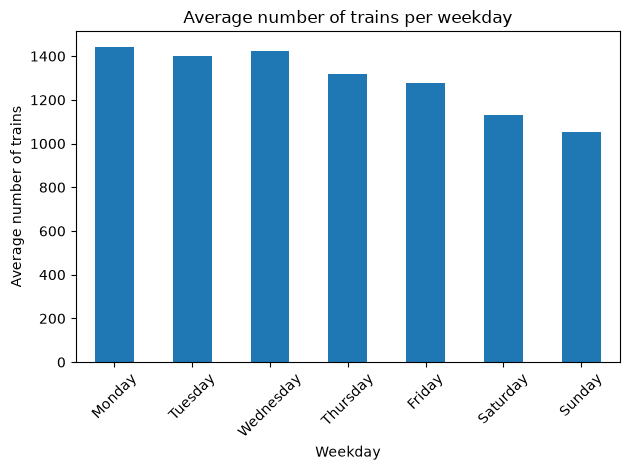

Number of trains on a wednesday on average: 1422.75 vs Number of trains on disrupted wednesday: 1420


In [43]:
weekday_counts = (
    counts_per_day
    .groupby('Weekday')['count']
    .mean()
    .reindex([
        'Monday', 'Tuesday', 'Wednesday',
        'Thursday', 'Friday', 'Saturday', 'Sunday'
    ])
)

weekday_counts.plot(kind='bar')

plt.xlabel('Weekday')
plt.ylabel('Average number of trains')
plt.title('Average number of trains per weekday')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Number of trains on a wednesday on average: {weekday_counts.iloc[2]} vs Number of trains on disrupted wednesday: {counts_per_day.loc[counts_per_day['Service:Date'] =='2026-01-06', 'count'].iloc[0]}")

In [33]:
train_intercity = train[train['Service:Type'] == 'Intercity']
train_sprinter = train[train['Service:Type'] == 'Sprinter']

train_other = train[~train['Service:Type'].isin(['Intercity', 'Sprinter'])]

#### Weather data

In [5]:
weather = pd.read_csv('weather_selected.csv')
weather.head()

,# STN,YYYYMMDD,HH,DD,FH,FF,FX,T,T10N,TD,...,VV,N,U,WW,IX,M,R,S,O,Y
0,260,20260101,1,250,40,40,90,44,NaN,10,...,50,8.0,78,NaN,NaN,0,0,0,0,0
1,260,20260101,2,240,50,50,90,45,NaN,7,...,65,8.0,76,NaN,NaN,0,0,0,0,0
2,260,20260101,3,240,50,50,100,45,NaN,5,...,80,8.0,75,NaN,NaN,0,0,0,0,0
3,260,20260101,4,240,50,50,100,43,NaN,5,...,82,8.0,76,NaN,NaN,0,0,0,0,0
4,260,20260101,5,240,60,60,110,45,NaN,4,...,82,8.0,74,NaN,NaN,0,0,0,0,0


# Data Pipeline